In [83]:
import importlib
import cosinorage as csa
import time

import utils
importlib.reload(utils)
from utils import recompute_wear_periods, plot_pig_wear_timeseries, save_modified_timeseries, compare_cohorts_daily_signal, load_cohort_data, plot_cohort_feature_comparison, filter_samples_by_wear_time_and_outliers, plot_cohort_demographics, sample_cohort_files

In [84]:
wear_file_name = "wear_periods_recomputed.csv"

### Computation of wear periods

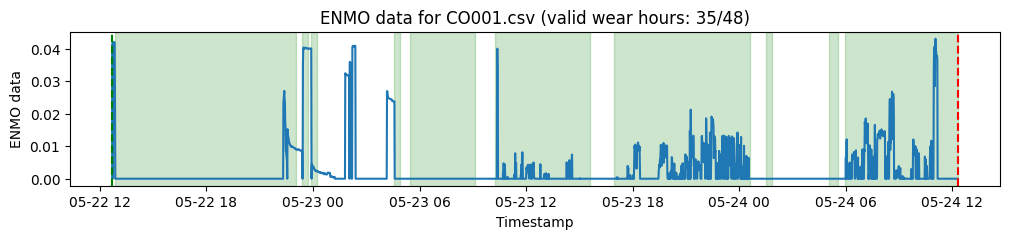

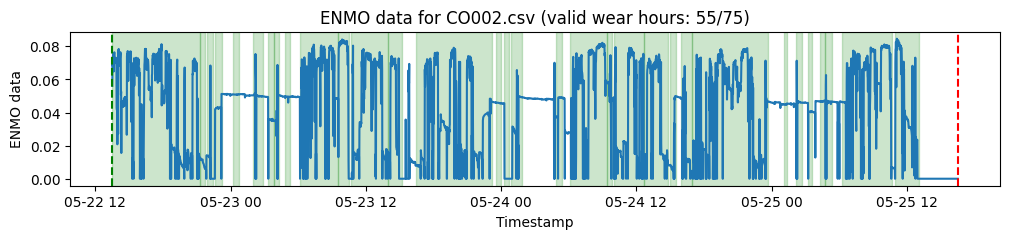

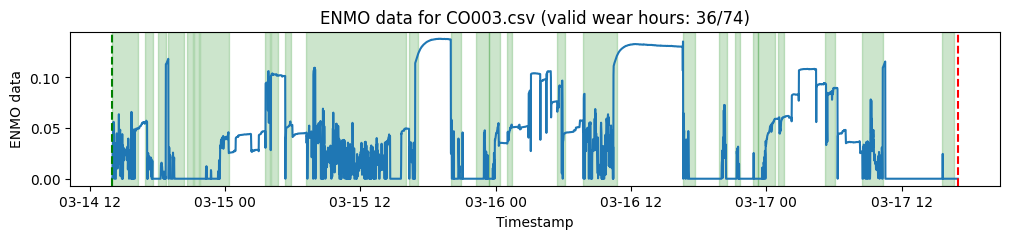

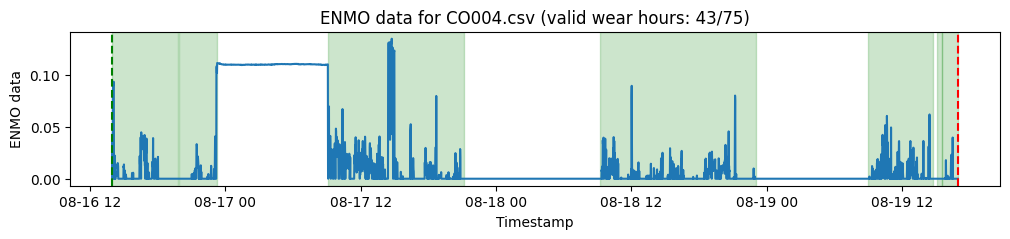

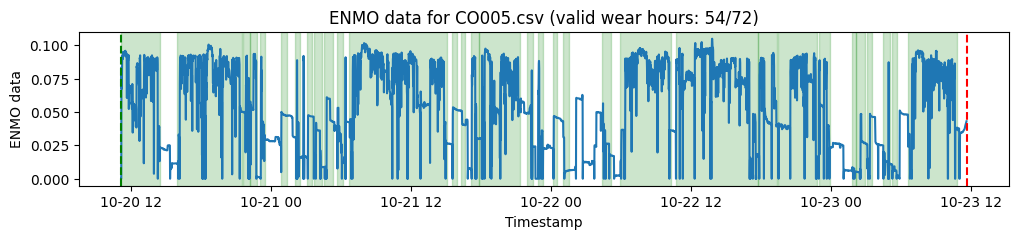

In [85]:
recompute_wear_periods(    
    sd_crit=0.015,
    range_crit=0.001,
    window_length=20,
    min_duration_minutes_wear=20
)
plot_pig_wear_timeseries(wear_file_name, "minute_level", limit=5, axis='enmo')

### Modification of values during during non-wear periods

During day time the mean of the timeseries is taken and during night time the values are set to 0.


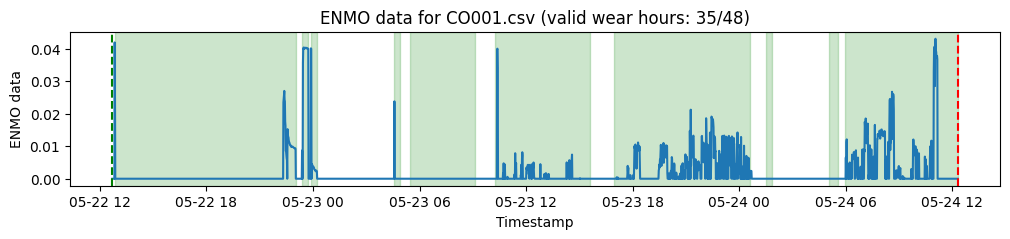

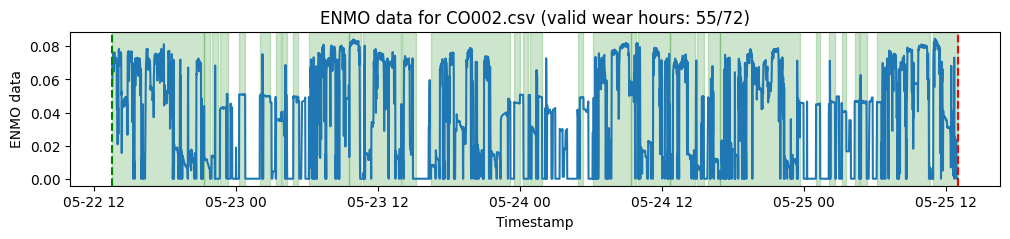

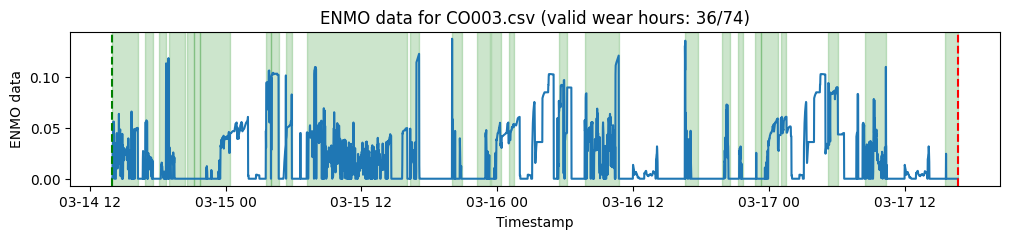

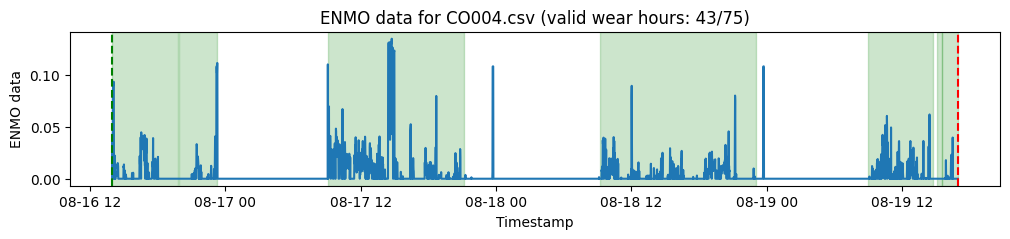

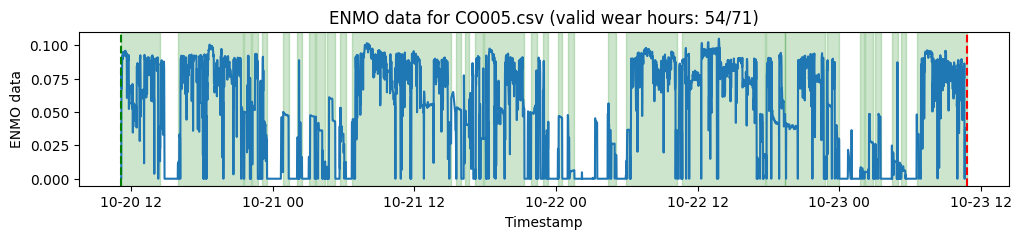

In [86]:
save_modified_timeseries(wear_file_name, "minute_level", output_dir="minute_level_modified", max_wear_periods=1000, day_start="07:00", day_end="22:00", smart=True)
plot_pig_wear_timeseries(wear_file_name, "minute_level_modified", limit=5, axis='enmo')

### Filter for samples with > 50% wear time and filter out outlier

In [87]:
#file_names = filter_samples_by_wear_time_and_outliers(
#    wear_csv=wear_file_name,
#    input_dir="minute_level",
#    min_wear_percentage=50.0,
#    outlier_method="iqr",
#    outlier_threshold=1.5,
#    output_file="filtered_samples.csv",
#    verbose=False
#)

file_names = sample_cohort_files(
    n_samples=5,
    random_seed=time.time(),
    verbose=True
)

print(file_names)

Using random seed: 1756985776.455092
Found 34 CO files and 20 FL files
Sampled 5 CO files and 5 FL files
CO samples: ['CO032.csv', 'CO023.csv', 'CO014.csv', 'CO002.csv', 'CO016.csv']
FL samples: ['FL019.csv', 'FL031.csv', 'FL011.csv', 'FL027.csv', 'FL008.csv']
Total sampled files: 10
['CO032.csv', 'CO023.csv', 'CO014.csv', 'CO002.csv', 'CO016.csv', 'FL019.csv', 'FL031.csv', 'FL011.csv', 'FL027.csv', 'FL008.csv']


In [88]:
"""
file_names = [
    "CO002.csv", "CO003.csv", "CO004.csv", "CO005.csv", "CO006.csv", "CO007.csv", "CO008.csv", "CO009.csv", "CO010.csv", "CO011.csv", "CO012.csv",
    "CO019.csv", "CO020.csv", "CO022.csv", "CO023.csv", "CO027.csv", "CO028.csv", "CO031.csv", "CO032.csv", "CO039.csv", "CO040.csv", "CO041.csv", "CO042.csv",
    "FL005.csv", "FL006.csv", "FL008.csv", "FL011.csv", "FL016.csv", "FL019.csv", "FL021.csv", "FL022.csv", "FL025.csv", "FL033.csv", "FL035.csv", "FL036.csv"
]
"""

'\nfile_names = [\n    "CO002.csv", "CO003.csv", "CO004.csv", "CO005.csv", "CO006.csv", "CO007.csv", "CO008.csv", "CO009.csv", "CO010.csv", "CO011.csv", "CO012.csv",\n    "CO019.csv", "CO020.csv", "CO022.csv", "CO023.csv", "CO027.csv", "CO028.csv", "CO031.csv", "CO032.csv", "CO039.csv", "CO040.csv", "CO041.csv", "CO042.csv",\n    "FL005.csv", "FL006.csv", "FL008.csv", "FL011.csv", "FL016.csv", "FL019.csv", "FL021.csv", "FL022.csv", "FL025.csv", "FL033.csv", "FL035.csv", "FL036.csv"\n]\n'

### Average circadian rhythm per cohort 

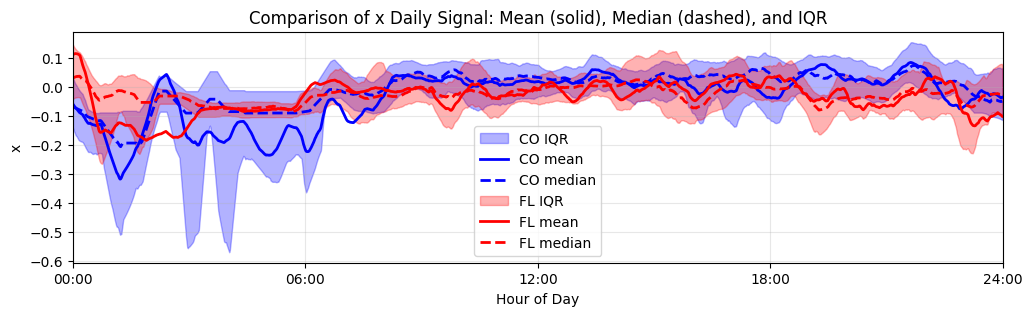

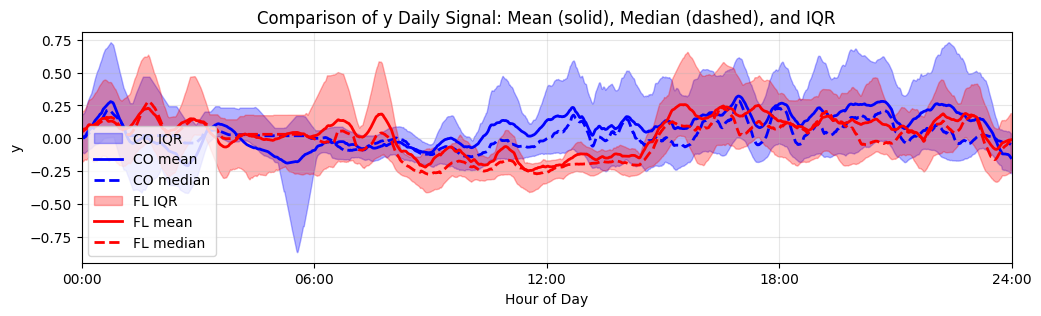

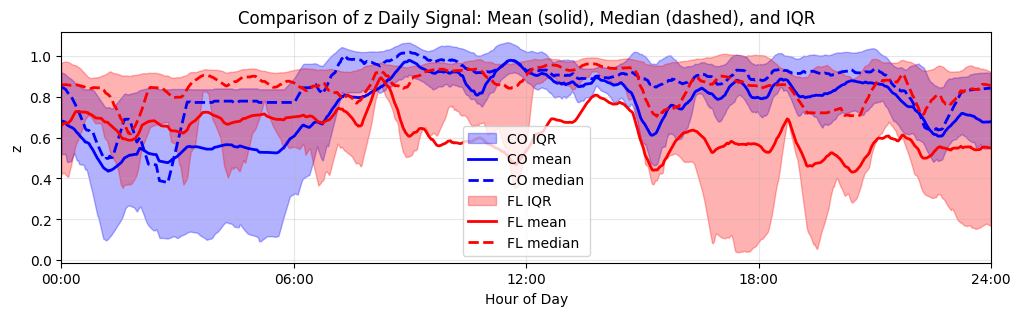

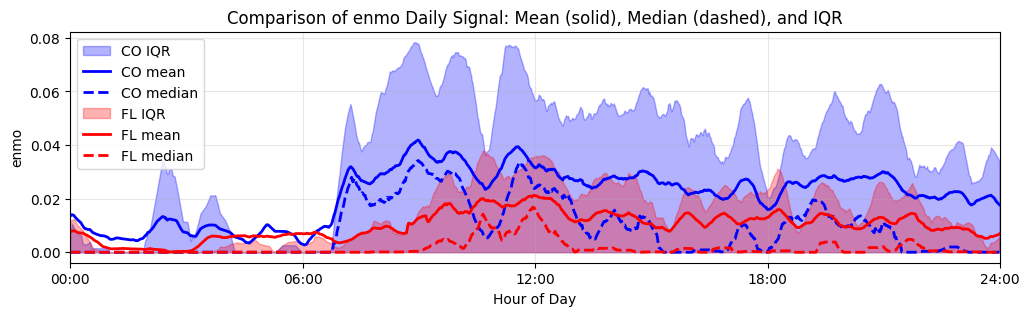

In [89]:
compare_cohorts_daily_signal(co_pattern="CO*.csv", fl_pattern="FL*.csv", folder="minute_level_modified", columns=['x','y','z','enmo'], window=30, plot_minmax=False, file_names=file_names)

### CosinorAge analysis per cohort

In [90]:
co_handlers, co_cosinor_age_inputs = load_cohort_data(modified_dir="minute_level_modified", header_dir="headers", pattern="CO*.csv", preprocess_args=None, file_names=file_names)
fl_handlers, fl_cosinor_age_inputs = load_cohort_data(modified_dir="minute_level_modified", header_dir="headers", pattern="FL*.csv", preprocess_args=None, file_names=file_names)

features_args = {}

co_features = csa.features.BulkWearableFeatures(
    handlers=co_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=co_cosinor_age_inputs
    )

fl_features = csa.features.BulkWearableFeatures(
    handlers=fl_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=fl_cosinor_age_inputs
    )

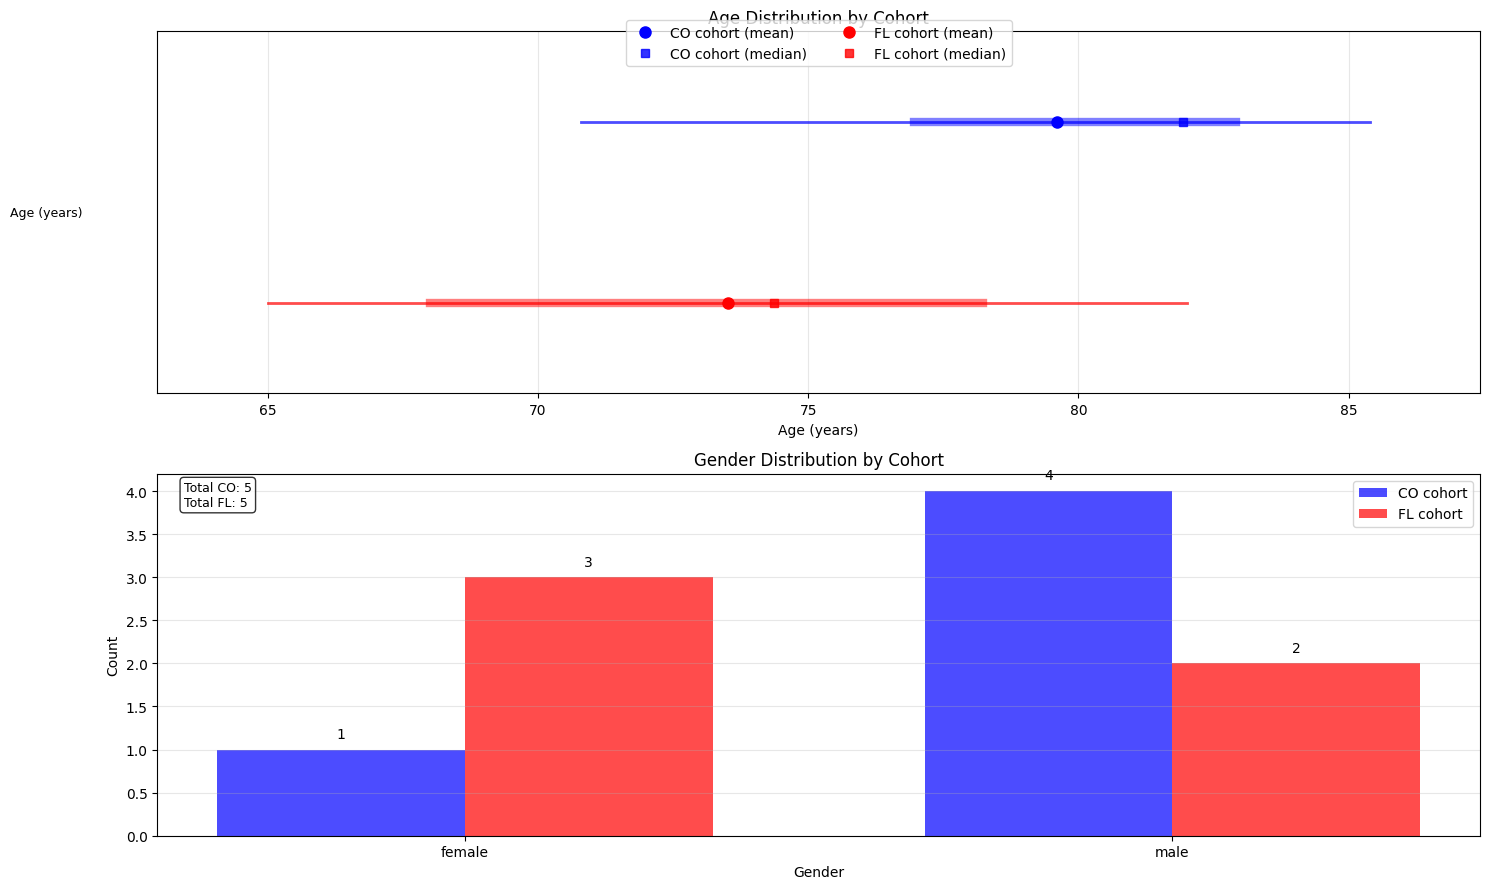

In [91]:
plot_cohort_demographics(co_cosinor_age_inputs=co_cosinor_age_inputs, fl_cosinor_age_inputs=fl_cosinor_age_inputs)

In [92]:
co_features.get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,5,20.171625,19.315857,0.089913,49.560471,10.571295,4.407176,36.229272,31.822096,0.089913,0.687674
1,cosinor_amplitude,5,12.035304,11.558899,0.131046,34.191208,8.500149,8.234138,9.119979,0.885840,0.131046,1.750042
2,cosinor_acrophase,5,-2.356493,1.435647,-4.047670,-0.501667,-2.862856,-3.543412,-0.826860,2.716552,-4.047670,0.334665
3,cosinor_acrophase_time,5,540.068430,329.026135,114.973604,927.657711,656.118254,189.502409,812.090172,622.587763,114.973604,-0.334665
4,nonparam_IS,5,0.843033,0.095321,0.748066,1.000000,0.784433,0.776785,0.905884,0.129099,0.748066,0.952575
5,nonparam_IV,5,0.984406,0.631693,0.348636,2.060217,0.628425,0.552922,1.331833,0.778911,0.348636,1.069969
6,nonparam_M10,5,29.972646,26.531597,0.215791,73.107854,19.242642,10.553281,46.743659,36.190378,0.215791,0.799287
7,nonparam_L5,5,4.370031,8.740062,0.000000,21.850155,0.000000,0.000000,0.000000,0.000000,0.000000,2.236068
8,nonparam_RA,5,0.872766,0.254468,0.363829,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,-2.236068
9,physical_activity_sedentary,5,850.700000,435.959700,305.000000,1430.500000,854.500000,434.500000,1229.000000,794.500000,305.000000,0.051997


In [93]:
fl_features.get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,5,8.121749,8.513428,1.018063,19.509856,1.324157,1.227395,17.529275,16.301880,1.018063,0.632592
1,cosinor_amplitude,5,6.995605,7.039198,1.495256,19.480514,2.120029,1.720354,10.161875,8.441521,1.495256,1.323793
2,cosinor_acrophase,5,-3.384597,1.258726,-5.140677,-1.518939,-2.963711,-4.370806,-2.928850,1.441956,-5.140677,0.043106
3,cosinor_acrophase_time,5,775.692393,288.478683,348.115265,1178.156290,679.232492,671.243007,1001.714912,330.471904,348.115265,-0.043106
4,nonparam_IS,5,0.737329,0.188625,0.421284,1.000000,0.755320,0.691507,0.818532,0.127025,0.421284,-0.577490
5,nonparam_IV,5,0.788225,0.352208,0.440416,1.217225,0.593046,0.477355,1.213083,0.735727,0.440416,0.519222
6,nonparam_M10,5,13.590819,13.708116,2.337055,34.255737,2.871594,2.623347,25.866362,23.243015,2.337055,0.775282
7,nonparam_L5,5,1.652609,3.305217,0.000000,8.263043,0.000000,0.000000,0.000000,0.000000,0.000000,2.236068
8,nonparam_RA,5,0.903919,0.192163,0.519593,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,-2.236068
9,physical_activity_sedentary,5,968.600000,344.551506,475.500000,1334.000000,1023.500000,680.000000,1330.000000,650.000000,475.500000,-0.348252


In [94]:
co_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.837196,-0.724918,0.724918,0.594096,-0.630252,0.992642,0.354815,-0.354815,-0.900390,...,-0.122180,0.901486,-0.800049,0.429788,-0.800046,-0.081881,-0.404821,0.398938,-0.588683,-0.730341
cosinor_amplitude,0.837196,1.000000,-0.761077,0.761077,0.922963,-0.812660,0.893690,-0.211793,0.211793,-0.611830,...,-0.074221,0.612412,-0.533635,-0.000313,-0.533633,-0.218594,-0.164786,0.321472,-0.785489,-0.795541
cosinor_acrophase,-0.724918,-0.761077,1.000000,-1.000000,-0.522032,0.965498,-0.776523,-0.052685,0.052685,0.798971,...,-0.548860,-0.797517,0.852842,-0.514213,0.852843,-0.465495,-0.335035,0.293401,0.196782,0.250768
cosinor_acrophase_time,0.724918,0.761077,-1.000000,1.000000,0.522032,-0.965498,0.776523,0.052685,-0.052685,-0.798971,...,0.548860,0.797517,-0.852842,0.514213,-0.852843,0.465495,0.335035,-0.293401,-0.196782,-0.250768
nonparam_IS,0.594096,0.922963,-0.522032,0.522032,1.000000,-0.662756,0.670888,-0.531951,0.531951,-0.261789,...,-0.234538,0.262635,-0.170384,-0.382924,-0.170382,-0.457297,-0.167332,0.405913,-0.889550,-0.816915
nonparam_IV,-0.630252,-0.812660,0.965498,-0.965498,-0.662756,1.000000,-0.707881,0.208361,-0.208361,0.633120,...,-0.520157,-0.631591,0.688605,-0.283242,0.688607,-0.356817,-0.404085,0.288045,0.301188,0.293672
nonparam_M10,0.992642,0.893690,-0.776523,0.776523,0.670888,-0.707881,1.000000,0.249219,-0.249219,-0.877715,...,-0.076539,0.878604,-0.787041,0.375411,-0.787038,-0.075142,-0.331759,0.357439,-0.621896,-0.740228
nonparam_L5,0.354815,-0.211793,-0.052685,0.052685,-0.531951,0.208361,0.249219,1.000000,-1.000000,-0.593092,...,0.000000,0.593749,-0.565682,0.821943,-0.565680,0.314270,-0.361084,0.078589,0.344675,0.108695
nonparam_RA,-0.354815,0.211793,0.052685,-0.052685,0.531951,-0.208361,-0.249219,-1.000000,1.000000,0.593092,...,0.000000,-0.593749,0.565682,-0.821943,0.565680,-0.314270,0.361084,-0.078589,-0.344675,-0.108695
physical_activity_sedentary,-0.900390,-0.611830,0.798971,-0.798971,-0.261789,0.633120,-0.877715,-0.593092,0.593092,1.000000,...,-0.222742,-0.999994,0.975568,-0.773624,0.975566,-0.332033,0.147863,-0.045074,0.179581,0.362676


In [95]:
fl_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.927646,-0.133028,0.133028,0.364289,-0.464844,0.991379,5.097395e-01,-5.097395e-01,-0.900281,...,-0.473628,0.911563,-0.937116,0.871990,-0.937116,-0.353486,-0.249228,0.341972,0.062934,-0.607695
cosinor_amplitude,0.927646,1.000000,-0.277109,0.277109,0.362453,-0.485522,0.968571,1.522837e-01,-1.522837e-01,-0.718221,...,-0.560966,0.732551,-0.833353,0.627003,-0.833354,-0.508685,-0.050173,0.152584,-0.211451,-0.840539
cosinor_acrophase,-0.133028,-0.277109,1.000000,-1.000000,0.762088,0.909134,-0.183380,2.334250e-01,-2.334250e-01,-0.281787,...,0.934833,0.254182,0.387503,0.128742,0.387506,0.967956,-0.922268,0.884185,-0.331751,0.128809
cosinor_acrophase_time,0.133028,0.277109,-1.000000,1.000000,-0.762088,-0.909134,0.183380,-2.334250e-01,2.334250e-01,0.281787,...,-0.934833,-0.254182,-0.387503,-0.128742,-0.387506,-0.967956,0.922268,-0.884185,0.331751,-0.128809
nonparam_IS,0.364289,0.362453,0.762088,-0.762088,1.000000,0.632444,0.372240,7.569586e-02,-7.569586e-02,-0.588375,...,0.566275,0.570656,-0.023414,0.331302,-0.023412,0.583049,-0.837823,0.866558,-0.664094,-0.534939
nonparam_IV,-0.464844,-0.485522,0.909134,-0.909134,0.632444,1.000000,-0.477546,-1.625395e-01,1.625395e-01,0.108808,...,0.982211,-0.136718,0.714602,-0.291612,0.714604,0.933808,-0.686881,0.629937,-0.525479,0.141237
nonparam_M10,0.991379,0.968571,-0.183380,0.183380,0.372240,-0.477546,1.000000,3.927434e-01,-3.927434e-01,-0.852318,...,-0.510007,0.864794,-0.915524,0.800801,-0.915525,-0.411703,-0.185830,0.283496,-0.034102,-0.700317
nonparam_L5,0.509739,0.152284,0.233425,-0.233425,0.075696,-0.162539,0.392743,1.000000e+00,-1.000000e+00,-0.710187,...,-0.009162,0.708455,-0.579705,0.859734,-0.579702,0.189107,-0.494711,0.504836,0.692030,0.342947
nonparam_RA,-0.509739,-0.152284,-0.233425,0.233425,-0.075696,0.162539,-0.392743,-1.000000e+00,1.000000e+00,0.710187,...,0.009162,-0.708455,0.579705,-0.859734,0.579702,-0.189107,0.494711,-0.504836,-0.692030,-0.342947
physical_activity_sedentary,-0.900281,-0.718221,-0.281787,0.281787,-0.588375,0.108808,-0.852318,-7.101874e-01,7.101874e-01,1.000000,...,0.076951,-0.999589,0.772348,-0.952376,0.772346,-0.075411,0.629708,-0.696893,-0.074627,0.401284


### Feature distribution per cohort

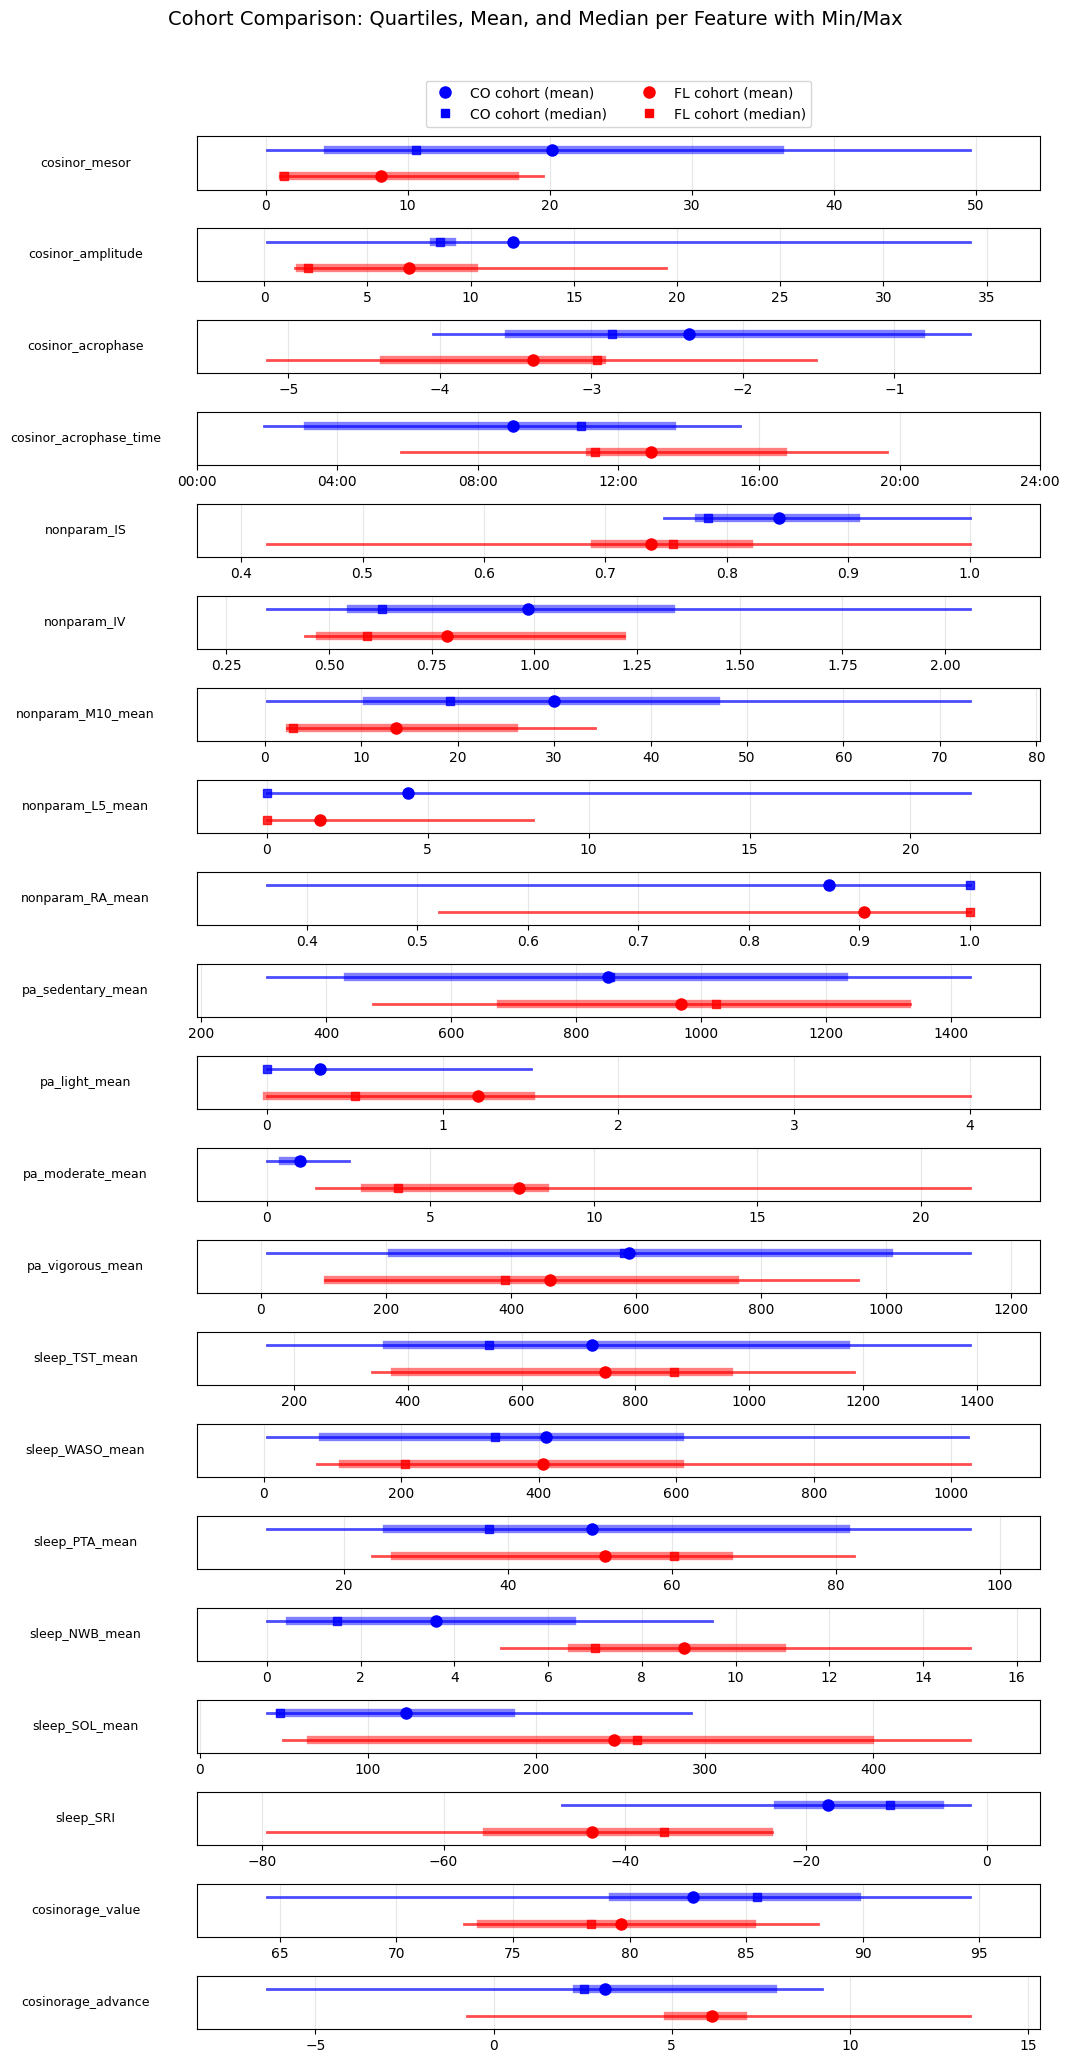

In [96]:
plot_cohort_feature_comparison(co_features, fl_features, title=None, plot_minmax=True)